# The transfer story, in the order it happened

Experiments were run sequentially, each batch chosen because of what the
previous one showed. That is the right way to run a screen and it is why the
evaluation grid is not a rectangle: the first block is exhaustive because
nothing was known yet, and everything after it is sparse because it followed
leads.

This notebook stays inside the exhaustive block: **every architecture at every
reduced action space that has been evaluated, one run each, no gate and no
target-grid training** — sixteen by five, 80 runs, as of this execution. Every
cell exists, so every mean, every marginal and every paired
contrast in this notebook is balanced by construction. Nothing here can be an
artifact of one arm having been given more attempts than another.

Three questions get an answer from that block alone:

1. **How large should the reduced action space be?**
2. **Does physical input scaling (`NLS`) help over the raw inputs (`NL`)?**
3. **Which architectures actually transfer?**

and the last section puts all three into a single picture.

The evaluation gate, the fine-tuned arms and the BC arm are all *later* blocks
built on the answers below. They are deliberately out of scope here.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
runs = data.runs
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "transfer_story"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


# The complete block: zero-shot, ungated, every architecture at every cap.
grid = runs.loc[
    (runs["route"] == "bus14 zero-shot") & (runs["gate"] == "ungated")
].copy()
VARIANTS = sorted(grid["variant"].unique())
# Derived from the runs, not hard-coded: a newly evaluated cap joins the grid
# on its own the next time this notebook is executed.
CAPS = W.caps_in(grid)

HARD = grid.pivot_table(index="variant", columns="mk", values="hard_pct")
CAPTURE = grid.pivot_table(index="variant", columns="mk", values="capture_hard_pct")
ORDER = HARD.mean(axis=1).sort_values(ascending=False).index.tolist()
HARD, CAPTURE = HARD.loc[ORDER], CAPTURE.loc[ORDER]
ALIVE = [v for v in ORDER if HARD.loc[v].max() >= 0.5]

assert len(grid) == len(VARIANTS) * len(CAPS), "the ungated block is no longer a full factorial"
display(Markdown(
    f"**{len(grid)} evaluations = {len(VARIANTS)} architectures x {len(CAPS)} action caps, "
    f"one per cell.**  \n"
    f"Metric: survival on the **{N_HARD} difficult chronics** — the ones do-nothing loses. "
    f"Do-nothing scores **{DN_HARD:.2f}%** there; the {N_EASY} easy chronics are excluded "
    f"because nothing can be won on them.  \n"
    f"**{len(ALIVE)} of {len(VARIANTS)}** architectures beat 0.5% somewhere on the grid; "
    f"the other {len(VARIANTS) - len(ALIVE)} lose the grid within a handful of steps at "
    f"every cap."
))

**80 evaluations = 16 architectures x 5 action caps, one per cell.**  
Metric: survival on the **24 difficult chronics** — the ones do-nothing loses. Do-nothing scores **8.34%** there; the 26 easy chronics are excluded because nothing can be won on them.  
**11 of 16** architectures beat 0.5% somewhere on the grid; the other 5 lose the grid within a handful of steps at every cap.

## 0. How the runs actually happened, and why the grid has holes

Four batches, each one launched because of what the previous one showed.

In [2]:
timeline = (
    runs.assign(block=np.select(
        [
            runs["route"] != "bus14 zero-shot",
            runs["gate"] == "gated",
        ],
        ["3-4. target-grid training", "2. gated screen"],
        default="1. zero-shot sweep",
    ))
    .groupby(["block", "route", "gate"], observed=True)
    .agg(evaluations=("key", "size"), architectures=("variant", "nunique"),
         caps=("mk", lambda s: ", ".join(f"mk{int(m)}" for m in sorted(set(s.dropna())))))
    .reset_index()
)
display(Markdown(f"""
| when | batch | what it was | why it looks like this |
|---|---|---|---|
| **15-16 Aug** | zero-shot sweep | 16 architectures x 5 caps, ungated | Nothing was known, so it was run exhaustively. **This is the block this notebook uses.** |
| **16-17 Aug** | local-rho gated screen | 38 evaluations on 8 of the 16 architectures, mk64/128/256 only | Launched *because* the sweep showed most architectures collapsing ungated. Only the checkpoints that looked salvageable were gated, and the promising ones got all four thresholds. |
| **16-18 Aug** | fine-tuning | mk256 aggressive, then mk64 conservative, 2 and 5 architectures | Launched on the architectures the first two blocks selected. |
| **18 Aug** | BC on greedy labels | 1 architecture at mk64 | Last, on the single cell that looked most promising. |

Each block is a rational response to the one before it, and the cost is that
**only the first block is a factorial.** Every later block is a conditional
sample: it contains the architectures that had already done well, evaluated
more thoroughly than the ones that had not. A maximum or a mean taken across
those blocks measures how many attempts each arm was given.

The plot below is the same coverage map as in `wcci_four_questions.ipynb`,
repeated here because it is the premise of everything that follows.
"""))
display(timeline)


| when | batch | what it was | why it looks like this |
|---|---|---|---|
| **15-16 Aug** | zero-shot sweep | 16 architectures x 5 caps, ungated | Nothing was known, so it was run exhaustively. **This is the block this notebook uses.** |
| **16-17 Aug** | local-rho gated screen | 38 evaluations on 8 of the 16 architectures, mk64/128/256 only | Launched *because* the sweep showed most architectures collapsing ungated. Only the checkpoints that looked salvageable were gated, and the promising ones got all four thresholds. |
| **16-18 Aug** | fine-tuning | mk256 aggressive, then mk64 conservative, 2 and 5 architectures | Launched on the architectures the first two blocks selected. |
| **18 Aug** | BC on greedy labels | 1 architecture at mk64 | Last, on the single cell that looked most promising. |

Each block is a rational response to the one before it, and the cost is that
**only the first block is a factorial.** Every later block is a conditional
sample: it contains the architectures that had already done well, evaluated
more thoroughly than the ones that had not. A maximum or a mean taken across
those blocks measures how many attempts each arm was given.

The plot below is the same coverage map as in `wcci_four_questions.ipynb`,
repeated here because it is the premise of everything that follows.


,block,route,gate,evaluations,architectures,caps
0,1. zero-shot sweep,bus14 zero-shot,ungated,80,16,"mk64, mk128, mk256, mk512, mk1024"
1,2. gated screen,bus14 zero-shot,gated,38,8,"mk64, mk128, mk256"
2,3-4. target-grid training,MAPPO fine-tune (aggressive),gated,8,2,mk256
3,3-4. target-grid training,MAPPO fine-tune (conservative),gated,8,8,mk64
4,3-4. target-grid training,MAPPO fine-tune (conservative),ungated,8,8,mk64
5,3-4. target-grid training,BC on greedy labels,gated,1,1,mk64
6,3-4. target-grid training,BC on greedy labels,ungated,1,1,mk64


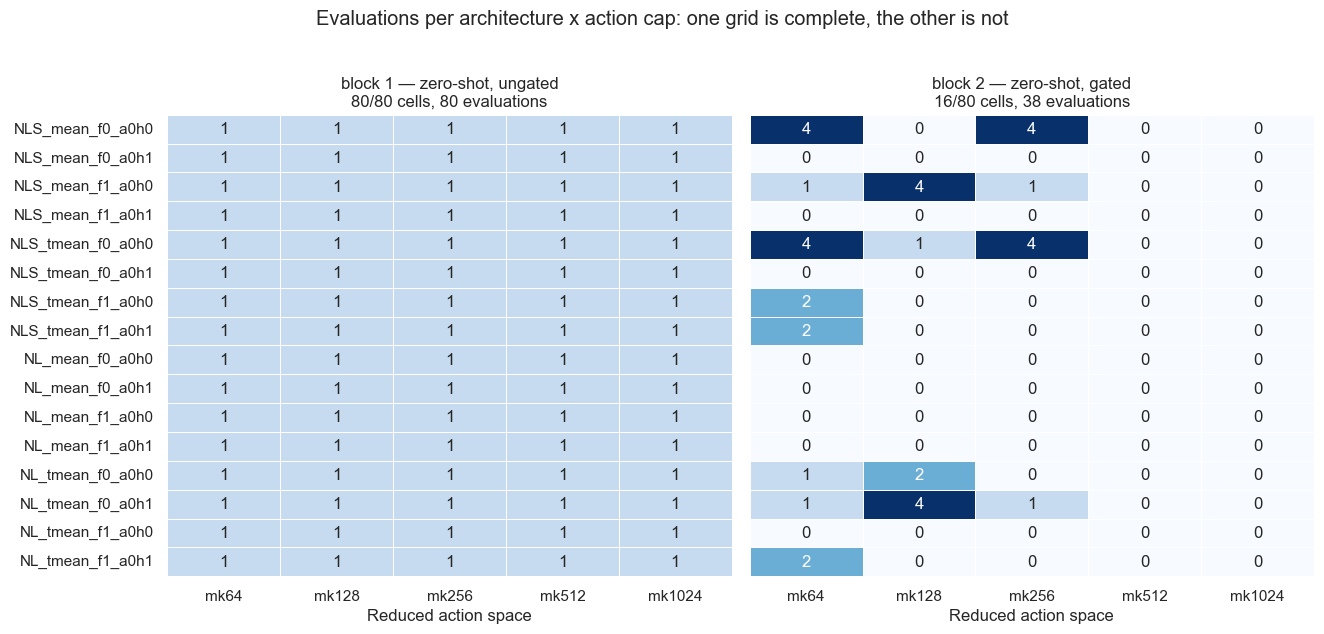

In [3]:
def coverage(frame):
    return (
        frame.pivot_table(index="variant", columns="mk", values="key",
                          aggfunc="size", fill_value=0, observed=True)
        .reindex(index=VARIANTS, columns=CAPS, fill_value=0)
    )


zero_all = runs.loc[runs["route"] == "bus14 zero-shot"]
cover_ungated = coverage(zero_all.loc[zero_all["gate"] == "ungated"])
cover_gated = coverage(zero_all.loc[zero_all["gate"] == "gated"])

fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.2), sharey=True)
for ax, cover, title in (
    (axes[0], cover_ungated, "block 1 — zero-shot, ungated"),
    (axes[1], cover_gated, "block 2 — zero-shot, gated"),
):
    sns.heatmap(cover, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=4,
                linewidths=0.6, linecolor="white", cbar=False, ax=ax)
    filled = int((cover.to_numpy() > 0).sum())
    ax.set(xlabel="Reduced action space", ylabel="",
           title=f"{title}\n{filled}/{cover.size} cells, "
                 f"{int(cover.to_numpy().sum())} evaluations")
    ax.set_xticklabels([f"mk{c}" for c in CAPS])
fig.suptitle("Evaluations per architecture x action cap: one grid is complete, the other is not",
             y=1.02)
fig.tight_layout()
save_figure(fig, "00_coverage")
plt.show()

## 1. The reduced action space: smaller wins

`k` caps how many topology actions each agent may choose from — the size of the
candidate set distilled from the teacher dataset. Every architecture was
evaluated at all five, so this contrast is paired inside each architecture: the
lines below are the same sixteen models, moved along the x-axis and nothing
else.

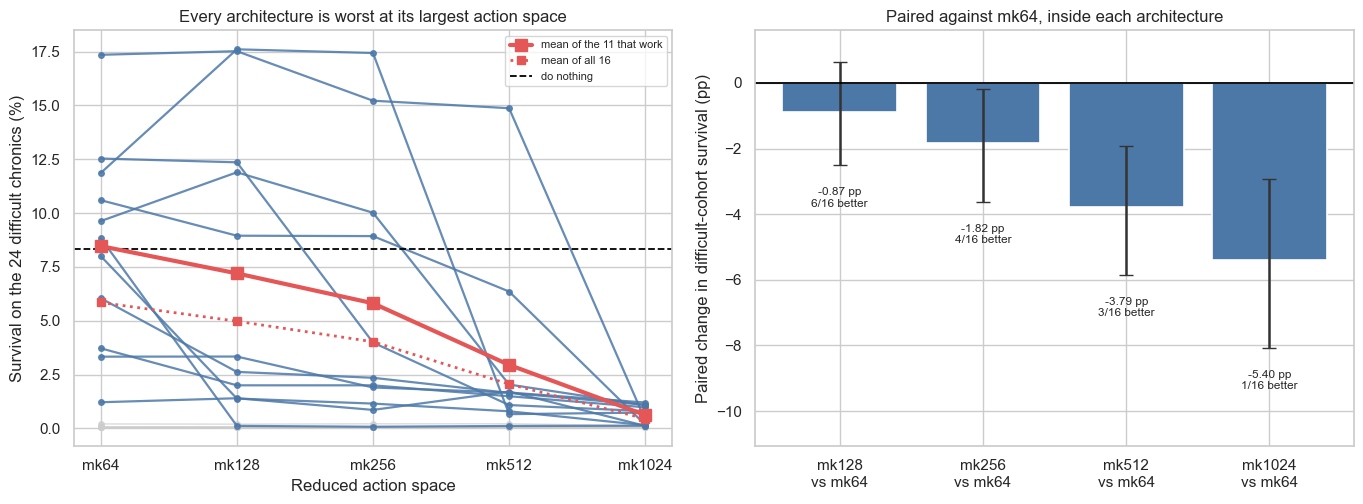

,mk,mean,lo,hi,better
0,128,-0.87,-2.50,0.62,6
1,256,-1.82,-3.62,-0.17,4
2,512,-3.79,-5.84,-1.92,3
3,1024,-5.40,-8.07,-2.92,1


#### Everything degrades together as the candidate set grows

,hard_mean,hard_mean_alive,hard_best,collapsed,easy_kept_mean,overall_mean
mk,,,,,,
64,5.85,8.46,17.35,5,10.50,25.33
128,4.97,7.20,17.60,6,7.69,19.85
256,4.02,5.81,17.43,6,6.38,16.95
512,2.05,2.95,14.87,6,4.75,13.17
1024,0.45,0.62,1.20,10,1.00,3.24


The ceiling moves with `k` too — the greedy oracle climbs from **67.9%** at mk64 to **94.9%** at mk256 — so raw survival could in principle be falling only because the target got harder to reach. It is not. `capture`, which puts do-nothing at 0 and that oracle at 100 at **each cap separately**, falls the same way over the architectures that work: **0.2%** -> **-1.9%** -> **-2.9%** -> **-7.8%** -> **-9.4%** from mk64 to mk1024.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

for variant in ORDER:
    alive = variant in ALIVE
    axes[0].plot(CAPS, HARD.loc[variant], marker="o", markersize=4,
                 linewidth=1.6 if alive else 1.0,
                 color="#4C78A8" if alive else "#CCCCCC",
                 alpha=0.85 if alive else 0.7, zorder=2 if alive else 1)
axes[0].plot(CAPS, HARD.loc[ALIVE].mean(), marker="s", markersize=8, linewidth=3.0,
             color="#E45756", zorder=3, label=f"mean of the {len(ALIVE)} that work")
axes[0].plot(CAPS, HARD.mean(), marker="s", markersize=6, linewidth=2.0,
             color="#E45756", linestyle=":", zorder=3, label="mean of all 16")
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.3, label="do nothing")
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="Every architecture is worst at its largest action space")
axes[0].legend(fontsize=8, loc="upper right")

deltas = HARD.sub(HARD[CAPS[0]], axis=0)
stats = []
for cap in CAPS[1:]:
    mean_d, lo, hi = W.paired_bootstrap(deltas[cap])
    stats.append({"mk": cap, "mean": mean_d, "lo": lo, "hi": hi,
                  "better": int((deltas[cap] > 0).sum())})
stats = pd.DataFrame(stats)
positions = np.arange(len(stats))
axes[1].bar(positions, stats["mean"], color="#4C78A8", edgecolor="white", linewidth=1.2)
axes[1].errorbar(positions, stats["mean"], yerr=[stats["mean"] - stats["lo"],
                                                 stats["hi"] - stats["mean"]],
                 fmt="none", ecolor="#333333", capsize=5, linewidth=1.8)
for x, row in zip(positions, stats.itertuples()):
    axes[1].annotate(f"{row.mean:+.2f} pp\n{row.better}/16 better", (x, row.lo),
                     xytext=(0, -30), textcoords="offset points", ha="center", fontsize=8.5)
axes[1].axhline(0, color="black", linewidth=1.3)
axes[1].set_xticks(positions, [f"mk{c}\nvs mk64" for c in stats["mk"]])
axes[1].set(ylabel="Paired change in difficult-cohort survival (pp)",
            title="Paired against mk64, inside each architecture")
axes[1].set_ylim(stats["lo"].min() - 3.0, max(stats["hi"].max(), 1) + 0.6)

for ax in (axes[0],):
    ax.set_xscale("log", base=2)
    ax.set_xticks(CAPS, [f"mk{c}" for c in CAPS])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel("Reduced action space")
fig.tight_layout()
save_figure(fig, "01_action_space")
plt.show()

display(stats.round(2))
display(Markdown("#### Everything degrades together as the candidate set grows"))
display(
    grid.groupby("mk").agg(
        hard_mean=("hard_pct", "mean"),
        hard_mean_alive=("hard_pct", lambda s: grid.loc[s.index].query("variant in @ALIVE")["hard_pct"].mean()),
        hard_best=("hard_pct", "max"),
        collapsed=("collapsed", "sum"),
        easy_kept_mean=("easy_kept", "mean"),
        overall_mean=("overall_pct", "mean"),
    )
)
display(Markdown(
    f"The ceiling moves with `k` too — the greedy oracle climbs from "
    f"**{data.greedy_hard[64]:.1f}%** at mk64 to **{data.greedy_hard[256]:.1f}%** at mk256 — "
    f"so raw survival could in principle be falling only because the target got harder to "
    f"reach. It is not. `capture`, which puts do-nothing at 0 and that oracle at 100 at "
    f"**each cap separately**, falls the same way over the architectures that work: "
    + " -> ".join(f"**{CAPTURE.loc[ALIVE, c].mean():.1f}%**" for c in CAPS)
    + " from mk64 to mk1024."
))

### What this says

**Use mk64 or mk128.** Nine of the sixteen architectures score their best at
mk64 and four more at mk128; only three peak higher, and none of those three is
among the models that work. Paired inside each architecture, mk128 is
statistically indistinguishable from mk64 (−0.87 pp, CI [−2.50, +0.62]), while
mk256 (−1.82 pp), mk512 (−3.79 pp) and mk1024 (−5.40 pp) are all clear losses
whose intervals exclude zero.

The degradation is not subtle and it is not a scoring artifact. Between mk64 and
mk1024 the number of architectures that collapse outright rises from 5 to 10 of
16, the average number of *easy* chronics still carried to the end falls from
10.5 to 1.0 of 26, and headroom capture — which renormalises against the
oracle at each cap — falls monotonically as well.

The mechanism is the obvious one. A larger candidate set does contain better
actions: the oracle proves it, climbing to 94.9% of the difficult cohort at
mk256. But the transferred scorer has to rank all of them from one forward pass,
on a grid whose action semantics it has never seen, and its discrimination does
not scale with the set. Past mk128 the extra candidates are noise it has to
reject, and it does not reject them.

**A small distilled action set is not a compromise here — it is the setting that
makes transfer work at all.**

## 2. Physical scaling: no effect on average, a large one in interaction

`NL` feeds the encoder raw power channels and the absolute voltage angle. `NLS`
divides the power channels by each grid's own maximum generator rating and
replaces the absolute angle with the drop along each line. It is a property of
the source training run, so the two halves of the grid are otherwise identical:
eight architecture cells x five caps, run in both conditions, forty matched
pairs.

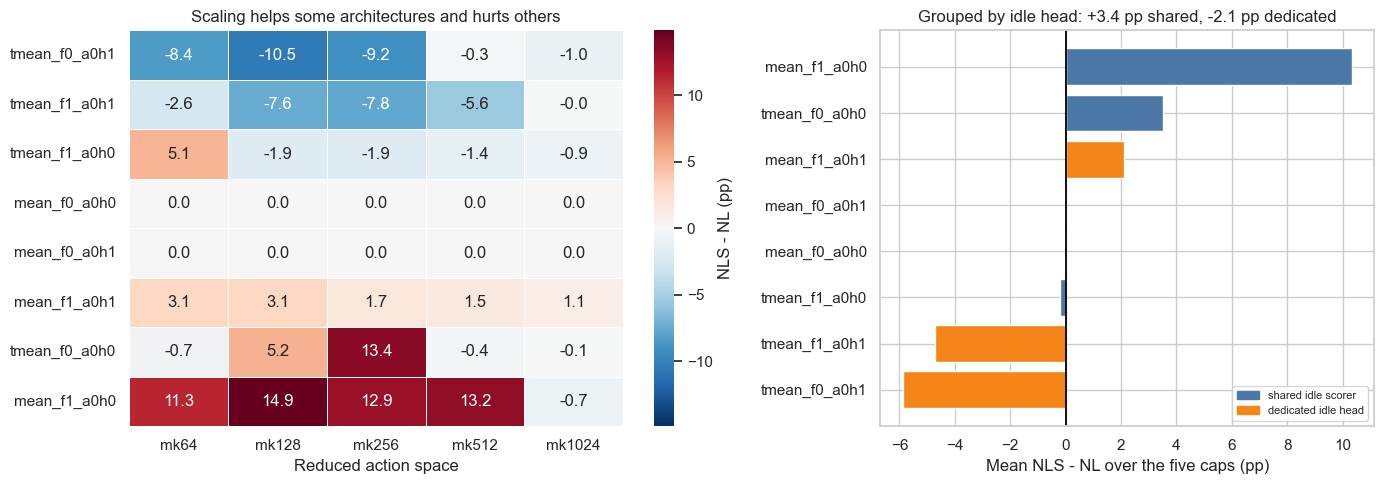

Over all **40** matched pairs, physical scaling is worth **+0.65 pp**, bootstrap CI **[-1.13, +2.53]** — an interval that contains zero. It wins **22** pairs and loses **18**, which is a coin flip.

,runs,mean,best,sd,collapsed
scaling,,,,,
physical scaling,40,3.79,17.60,6.04,17
raw inputs,40,3.14,12.53,4.12,16


#### The same 40 pairs, split by the idle head

,pairs,mean_pp,wins
idle,,,
dedicated idle head,20,-2.11,10
shared idle scorer,20,3.41,12


In [5]:
pairs = W.matched_pairs(grid, "scaling", ("raw inputs", "physical scaling"),
                        ["pool", "features", "head", "mk"])
mean_s, lo_s, hi_s = W.paired_bootstrap(pairs["delta"])
pairs["cell"] = (pairs["pool"] + "_f" + pairs["features"].astype(str)
                 + "_a0h" + pairs["head"].astype(str))
matrix = pairs.pivot_table(index="cell", columns="mk", values="delta")
matrix = matrix.loc[matrix.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0),
                         gridspec_kw={"width_ratios": [1.25, 1]})
limit = np.abs(matrix.to_numpy()).max()
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            vmin=-limit, vmax=limit, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "NLS - NL (pp)"}, ax=axes[0])
axes[0].set(xlabel="Reduced action space", ylabel="",
            title="Scaling helps some architectures and hurts others")
axes[0].set_xticklabels([f"mk{c}" for c in CAPS])

by_head = matrix.mean(axis=1).rename("mean_delta").reset_index()
by_head["idle"] = np.where(by_head["cell"].str.endswith("a0h0"),
                           "shared idle scorer", "dedicated idle head")
colours = {"shared idle scorer": "#4C78A8", "dedicated idle head": "#F58518"}
axes[1].barh(by_head["cell"], by_head["mean_delta"],
             color=[colours[i] for i in by_head["idle"]], edgecolor="white", linewidth=1.0)
axes[1].axvline(0, color="black", linewidth=1.3)
shared = by_head.loc[by_head["idle"] == "shared idle scorer", "mean_delta"].mean()
dedicated = by_head.loc[by_head["idle"] == "dedicated idle head", "mean_delta"].mean()
axes[1].set(xlabel="Mean NLS - NL over the five caps (pp)", ylabel="",
            title=f"Grouped by idle head: {shared:+.1f} pp shared, {dedicated:+.1f} pp dedicated")
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in colours.items()],
               fontsize=8, loc="lower right")
fig.tight_layout()
save_figure(fig, "02_scaling")
plt.show()

display(Markdown(
    f"Over all **{len(pairs)}** matched pairs, physical scaling is worth "
    f"**{mean_s:+.2f} pp**, bootstrap CI **[{lo_s:+.2f}, {hi_s:+.2f}]** — an interval that "
    f"contains zero. It wins **{int((pairs['delta'] > 0).sum())}** pairs and loses "
    f"**{int((pairs['delta'] < 0).sum())}**, which is a coin flip."
))
display(
    grid.groupby("scaling").agg(
        runs=("key", "size"), mean=("hard_pct", "mean"), best=("hard_pct", "max"),
        sd=("hard_pct", "std"), collapsed=("collapsed", "sum"),
    )
)
display(Markdown("#### The same 40 pairs, split by the idle head"))
display(
    pairs.assign(idle=np.where(pairs["head"] == 0, "shared idle scorer", "dedicated idle head"))
    .groupby("idle").agg(pairs=("delta", "size"), mean_pp=("delta", "mean"),
                         wins=("delta", lambda s: int((s > 0).sum())))
)

### What this says

**On its own, scaling does nothing measurable** — `+0.65 pp` over forty pairs
with an interval spanning zero, 22 wins to 18 losses. If the question is "does
the correction help", the honest answer from the complete grid is that this
experiment cannot tell.

**But the average is hiding a large and structured spread.** The eight cells
range from **+10.3 pp** to **−5.9 pp**, and the heat map shows those signs are
stable across caps rather than flipping cell by cell — the same cell is red or
blue at mk64, mk128, mk256 and mk512, and everything washes out at mk1024 where
every model is dead anyway. That is not the pattern of noise.

Grouped by the idle head, the split is **+3.4 pp** for the shared scorer against
**−2.1 pp** for the dedicated head. It is not a clean partition — `mean_f1_a0h1`
is dedicated and still gains +2.1 pp — but the two large negatives are both
`tmean_*_a0h1`, and the two large positives are both `*_a0h0`:

* `mean_f1_a0h0` **+10.3 pp** — this is what makes it the best model on the grid;
* `tmean_f0_a0h0` **+3.5 pp**;
* `tmean_f0_a0h1` **−5.9 pp** and `tmean_f1_a0h1` **−4.7 pp**;
* the two `mean_f0` cells: exactly 0.0, because those models are dead in both
  conditions and nothing can move them.

A reading that fits, offered as a hypothesis and not a result: with a shared
scorer, do-nothing competes against real actions through the same pathway, so
the scale of the input features sets how often anything at all beats it, and
correcting that scale on a new grid matters. With a dedicated head, that
decision is made by separate parameters the correction does not touch, and the
rescaling only perturbs the ranking among the actions. Eight cells at one seed
cannot test that; what they do establish is that **the correct answer to "should
we use physical scaling" is architecture-dependent, so the grid average is the
wrong summary to quote either way.**

The other visible thing is dispersion. `NLS` has both the best run on the grid
(17.6%) and the same floor as `NL`, with a standard deviation half again as
large. It raises the ceiling without raising the floor.

## 3. Which architectures actually transfer

Sixteen models, each averaged over its five caps. The question is not which
scores highest — one seed cannot settle that — but whether the ordering has
structure, and it does.

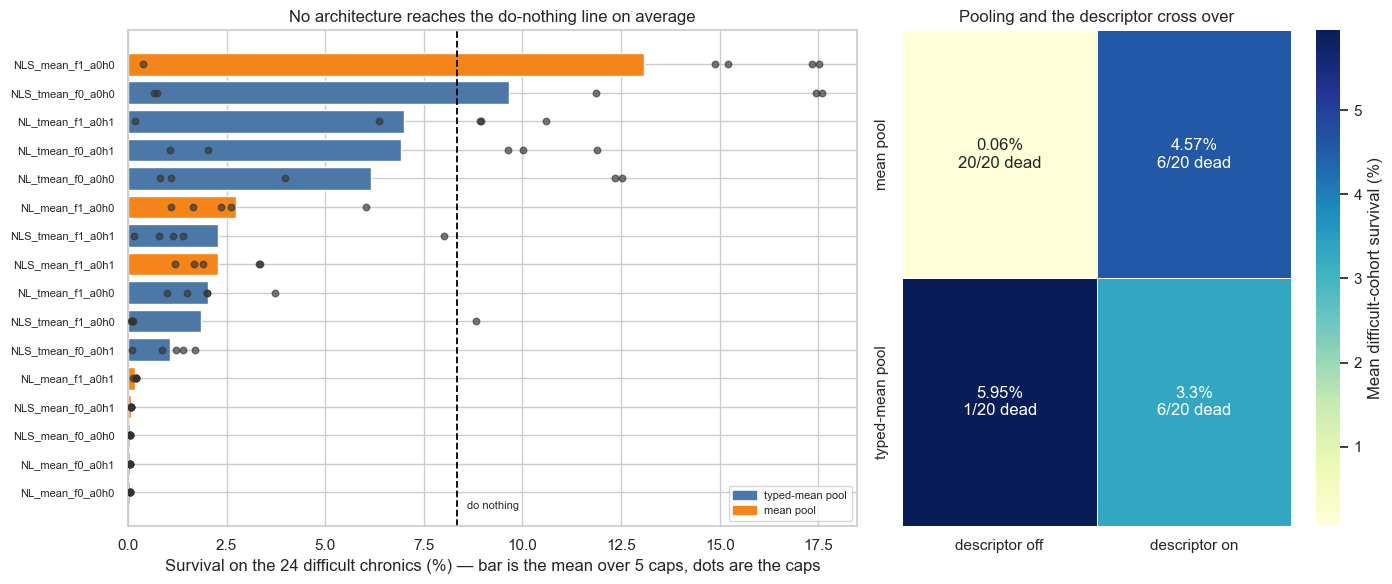

,variant,scaling,pooling,descriptor,idle,hard_mean,hard_best,collapsed,easy_kept
2,NLS_mean_f1_a0h0,physical scaling,mean pool,descriptor on,shared idle scorer,13.07,17.52,1,18.60
4,NLS_tmean_f0_a0h0,physical scaling,typed-mean pool,descriptor off,shared idle scorer,9.66,17.60,0,18.40
15,NL_tmean_f1_a0h1,raw inputs,typed-mean pool,descriptor on,dedicated idle head,7.00,10.60,1,10.20
13,NL_tmean_f0_a0h1,raw inputs,typed-mean pool,descriptor off,dedicated idle head,6.93,11.89,0,21.00
12,NL_tmean_f0_a0h0,raw inputs,typed-mean pool,descriptor off,shared idle scorer,6.15,12.53,0,7.60
10,NL_mean_f1_a0h0,raw inputs,mean pool,descriptor on,shared idle scorer,2.75,6.04,0,3.20
7,NLS_tmean_f1_a0h1,physical scaling,typed-mean pool,descriptor on,dedicated idle head,2.29,8.00,1,13.60
3,NLS_mean_f1_a0h1,physical scaling,mean pool,descriptor on,dedicated idle head,2.29,3.33,0,0.00
14,NL_tmean_f1_a0h0,raw inputs,typed-mean pool,descriptor on,shared idle scorer,2.04,3.72,0,0.00
6,NLS_tmean_f1_a0h0,physical scaling,typed-mean pool,descriptor on,shared idle scorer,1.85,8.83,4,4.20


In [6]:
ranking = (
    grid.groupby(["variant", "scaling", "pooling", "descriptor", "idle"],
                 as_index=False, observed=True)
    .agg(hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"),
         collapsed=("collapsed", "sum"), easy_kept=("easy_kept", "mean"))
    .sort_values("hard_mean")
)
POOL_COLORS = {"typed-mean pool": "#4C78A8", "mean pool": "#F58518"}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.0),
                         gridspec_kw={"width_ratios": [1.5, 1]})
positions = np.arange(len(ranking))
axes[0].barh(positions, ranking["hard_mean"],
             color=[POOL_COLORS[p] for p in ranking["pooling"]],
             edgecolor="white", linewidth=1.0)
for y, variant in zip(positions, ranking["variant"]):
    axes[0].scatter(HARD.loc[variant], [y] * len(CAPS), s=22, color="#333333",
                    alpha=0.65, zorder=3)
axes[0].axvline(DN_HARD, color="black", linestyle="--", linewidth=1.3)
axes[0].text(DN_HARD + 0.25, -0.6, "do nothing", fontsize=8)
axes[0].set_yticks(positions, ranking["variant"], fontsize=8)
axes[0].set(xlabel=f"Survival on the {N_HARD} difficult chronics (%) — bar is the mean over "
                   f"5 caps, dots are the caps",
            title="No architecture reaches the do-nothing line on average")
axes[0].legend(handles=[Patch(color=c, label=k) for k, c in POOL_COLORS.items()],
               fontsize=8, loc="lower right")

cells = grid.pivot_table(index="pooling", columns="descriptor", values="hard_pct",
                         aggfunc="mean", observed=True)
collapses = grid.pivot_table(index="pooling", columns="descriptor", values="collapsed",
                             aggfunc="sum", observed=True)
labels = (cells.round(2).astype(str) + "%\n" + collapses.astype(str) + "/20 dead")
sns.heatmap(cells, annot=labels.to_numpy(), fmt="", cmap="YlGnBu", linewidths=0.6,
            linecolor="white", cbar_kws={"label": "Mean difficult-cohort survival (%)"},
            ax=axes[1])
axes[1].set(xlabel="", ylabel="", title="Pooling and the descriptor cross over")
fig.tight_layout()
save_figure(fig, "03_architectures")
plt.show()

display(ranking.sort_values("hard_mean", ascending=False))

### What this says

**Read the bottom of the ranking first.** Four architectures score 0.05–0.07% at
every single cap: they lose the grid within a handful of steps, always. All four
are `mean` pooling with the descriptor **off** — and the heat map shows that cell
is 20 of 20 dead, mean survival 0.06%, with **zero** of the 26 easy chronics
kept on average. That is not underperformance, it is a policy that actively
destroys a grid do-nothing would have carried to the end.

The mechanism is legible. With a joint mean over the touched-node embeddings and
no static action descriptor, two candidate actions that touch the same nodes
produce the *same vector*. The scorer has nothing to rank. Give it either fix —
per-type pooling, or the descriptor — and it recovers.

The two fixes are alternatives, not additions. Typed-mean **without** the
descriptor is the strongest cell on the grid (5.95%, 1 of 20 dead, 11.8 easy
chronics kept); adding the descriptor on top makes it *worse* (3.30%, 6 of 20
dead). Mean pooling with the descriptor lands in between. Whatever the scorer
needs to tell candidates apart, per-type pooling supplies it better, and
supplying it twice interferes.

**The top of the ranking is two models, and they are not the same recipe:**

* `NLS_mean_f1_a0h0` — 13.07% mean, best on the grid at four of five caps, and
  the model that section 2's interaction is really about: mean pooling rescued by
  the descriptor, plus scaling, plus the shared idle scorer.
* `NLS_tmean_f0_a0h0` — 9.66% mean and the single highest score anywhere on the
  grid (17.60% at mk128): the clean recipe, per-type pooling with nothing bolted
  on.

Both are `NLS` and both are `a0h0`. Every architecture in the top five uses the
shared idle scorer or typed-mean pooling or both.

**And the honest headline: no architecture averages above the do-nothing floor.**
The best mean on the grid is 13.07% against a floor of 8.34%, and that is a mean
over caps that includes mk1024 where it collapses. Ungated zero-shot transfer,
taken as a whole, is not yet a working system — which is exactly why the next
block of experiments was a gate.

## 4. All three answers in one picture

The grid is small enough to show whole. Rows are architectures ordered by mean,
columns are action caps, colour is difficult-cohort survival. The bar above each
column is the cap's mean and the bar beside each row is the architecture's mean;
the strip on the left marks the input condition.

Everything in the three sections above is visible in it: the columns fade to the
right (§1), the left strip alternates without an obvious pattern until you look
at the top four rows (§2), and the rows split into a live upper half and a dead
lower half (§3).

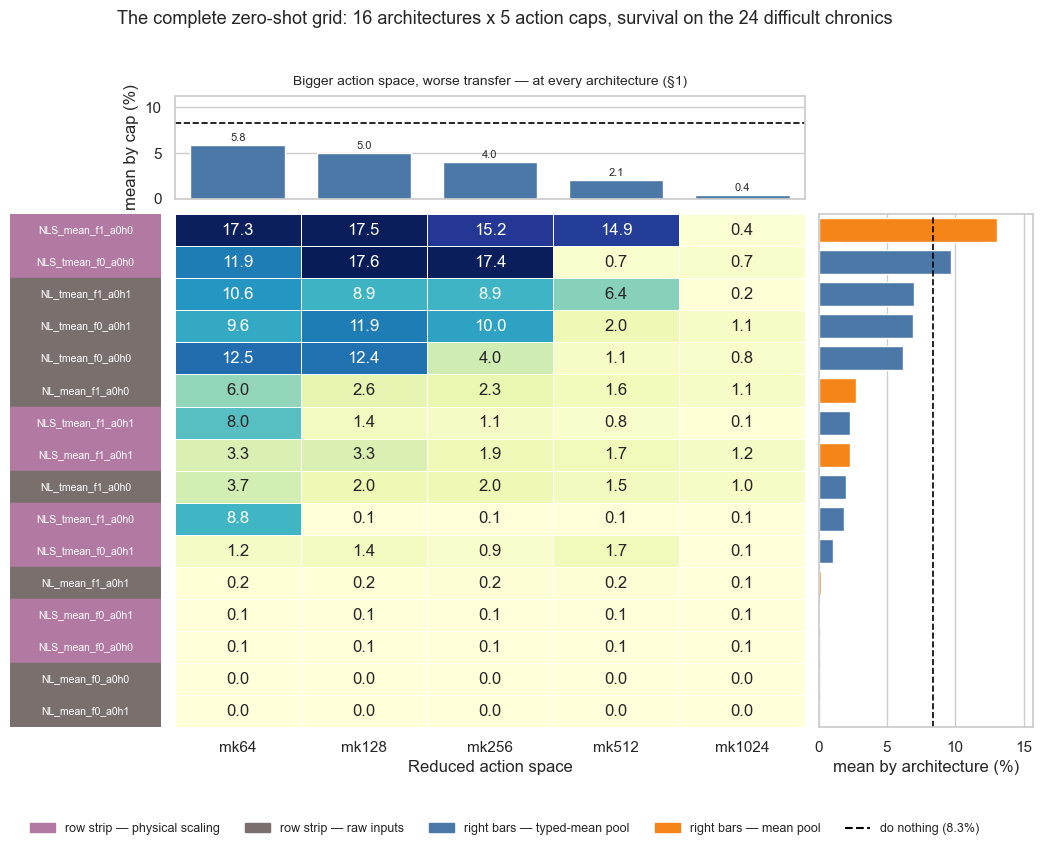

In [7]:
fig = plt.figure(figsize=(13.2, 8.2))
gs = fig.add_gridspec(2, 3, width_ratios=[0.24, 1, 0.34], height_ratios=[0.20, 1],
                      wspace=0.04, hspace=0.05)
ax_strip = fig.add_subplot(gs[1, 0])
ax_main = fig.add_subplot(gs[1, 1])
ax_right = fig.add_subplot(gs[1, 2])
ax_top = fig.add_subplot(gs[0, 1])

sns.heatmap(HARD, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.7, linecolor="white",
            cbar=False, ax=ax_main, vmin=0, vmax=HARD.to_numpy().max())
ax_main.set(xlabel="Reduced action space", ylabel="")
ax_main.set_xticklabels([f"mk{c}" for c in CAPS])
ax_main.set_yticklabels([])

SCALE_COLORS = {"NLS": "#B279A2", "NL": "#79706E"}  # distinct from the pooling palette
for y, variant in enumerate(ORDER):
    family = "NLS" if variant.startswith("NLS") else "NL"
    ax_strip.add_patch(plt.Rectangle((0, y), 1, 1, color=SCALE_COLORS[family]))
    ax_strip.text(0.5, y + 0.5, variant, ha="center", va="center",
                  fontsize=7.5, color="white")
ax_strip.set(xlim=(0, 1), ylim=(len(ORDER), 0), xticks=[], yticks=[])
ax_strip.grid(False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

ax_top.bar(np.arange(len(CAPS)) + 0.5, HARD.mean(), width=0.75, color="#4C78A8",
           edgecolor="white", linewidth=1.0)
for x, value in enumerate(HARD.mean()):
    ax_top.annotate(f"{value:.1f}", (x + 0.5, value), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8)
ax_top.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_top.set(xlim=(0, len(CAPS)), xticks=[], ylabel="mean by cap (%)")
ax_top.set_ylim(0, max(HARD.mean().max(), DN_HARD) * 1.35)
ax_top.set_title("Bigger action space, worse transfer — at every architecture (§1)",
                 fontsize=10, pad=8)

row_means = HARD.mean(axis=1)
pool_of = grid.drop_duplicates("variant").set_index("variant")["pooling"]
ax_right.barh(np.arange(len(ORDER)) + 0.5, row_means,
              color=[POOL_COLORS[pool_of[v]] for v in ORDER],
              edgecolor="white", linewidth=1.0, height=0.75)
ax_right.axvline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_right.set(ylim=(len(ORDER), 0), yticks=[], xlabel="mean by architecture (%)")
ax_right.set_xlim(0, max(row_means.max(), DN_HARD) * 1.2)

handles = (
    [Patch(color=c, label=f"row strip — {W.SCALING_LABELS[k]}") for k, c in SCALE_COLORS.items()]
    + [Patch(color=c, label=f"right bars — {k}") for k, c in POOL_COLORS.items()]
    + [plt.Line2D([], [], color="black", linestyle="--", label=f"do nothing ({DN_HARD:.1f}%)")]
)
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.035), frameon=False)
fig.suptitle(
    f"The complete zero-shot grid: {len(VARIANTS)} architectures x {len(CAPS)} action caps, "
    f"survival on the {N_HARD} difficult chronics",
    y=0.985, fontsize=13,
)
save_figure(fig, "04_summary")
plt.show()

### The whole block in four sentences

1. **The action set should be small.** Survival falls monotonically with `k` at
   every architecture that works, and mk1024 kills ten of sixteen models
   outright — a paired effect of −5.4 pp against mk64, and not a consequence of
   the oracle's ceiling moving.
2. **Physical scaling is not a main effect** — +0.65 pp over 40 pairs with an
   interval spanning zero — but it is not noise either: it ranges from +10.3 pp
   to −5.9 pp with signs stable across caps, and groups +3.4 vs −2.1 pp by the
   idle head. Quote it per architecture, never as a grid average.
3. **One architectural choice separates working models from destructive ones:**
   the scorer must be able to tell two candidates apart, whether by per-type
   pooling or by the action descriptor. Supply neither and 20 of 20 runs destroy
   the grid; supply both and they interfere.
4. **None of it is enough on its own.** The best architecture averages 13.07%
   against a do-nothing floor of 8.34%, and the grid's single best run reaches
   17.60%. That is the finding that made the next batch a gated screen rather
   than more architectures.

In [8]:
exports = {
    "grid_hard_pct.csv": HARD.reset_index(),
    "grid_capture_pct.csv": CAPTURE.reset_index(),
    "action_space_paired.csv": stats,
    "scaling_pairs.csv": pairs,
    "architecture_ranking.csv": ranking.sort_values("hard_mean", ascending=False),
    "coverage.csv": cover_ungated.reset_index(),
}
for name, table in exports.items():
    table.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 5 figures written to:\n{EXPORT_DIR}")

6 tables + 5 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/transfer_story
